In [59]:
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

### Function to Create a Network

In [60]:
def create_network(network_type, num_nodes, seed = None, p = 0.01, m = 5, k = 6):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    if network_type == 'Erdos-Reyni':
        return nx.erdos_renyi_graph(num_nodes, p, seed)
    elif network_type == 'Barabasi-Albert':
        return nx.barabasi_albert_graph(num_nodes, m, seed)
    elif network_type == 'Watts-Strogatz':
        return nx.watts_strogatz_graph(num_nodes, k, p, seed)
    else:
        raise ValueError("Invalid network type. Choose from 'Erdos-Reyni', 'Barabasi-Albert', or 'Watts-Strogatz'.")

### Function to Run the Simulation on an SIR Model 

In [61]:
# Function to run SIR simulation
def run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations=100,seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)   
    # Configuring the model
    model = ep.SIRModel(network)
    config = mc.Configuration()

    #Add model Parameters 
    config.add_model_parameter('beta', beta) 
    config.add_model_parameter('gamma', gamma)  
    config.add_model_parameter('percentage_infected', initial_infected_fraction)  # Initial infected population 
    model.set_initial_status(config)

    trends = model.iteration_bunch(iterations)

    susceptible = [trend['node_count'][0] for trend in trends]
    infected = [trend['node_count'][1] for trend in trends]
    recovered = [trend['node_count'][2] for trend in trends]

    return susceptible, infected, recovered

### Function to Plot SIR Results

In [62]:
# Function to plot SIR curves for all combinations of beta and gamma
def plot_sir_results(results):
    num_plots = len(results)
    cols = 3  # Number of columns in the plot grid
    rows = (num_plots // cols) + (num_plots % cols > 0)  # Calculate number of rows needed
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array to easily iterate through it

    for idx, ((beta, gamma), (susceptible, infected, recovered)) in enumerate(results.items()):
        ax = axes[idx]
        ax.plot(susceptible, label='Susceptible', color='blue')
        ax.plot(infected, label='Infected', color='red')
        ax.plot(recovered, label='Recovered', color='green')

        ax.set_title(f"Beta: {beta}, Gamma: {gamma}")
        ax.set_xlabel('Iterations')
        ax.set_ylabel('Population')
        ax.legend()

    # Hide any unused subplots
    for idx in range(len(results), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

### Function to Run Experiments with Varying Parameters

In [63]:
# Function to run experiments with varying parameters
def experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', num_nodes=100, initial_infected_fraction=0.01, iterations=100):
    results = {}

    # Create the network
    network = create_network(network_type, num_nodes, p = 0.1, seed = 10)

    # Run SIR simulations for all combinations of beta and gamma
    for beta in beta_values:
        for gamma in gamma_values:
            susceptible, infected, recovered = run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations)
            results[(beta, gamma)] = (susceptible, infected, recovered)

            plt.plot(infected, label=f'Beta: {beta}, Gamma: {gamma}')
    
    plt.title(f'SIR Model on {network_type.capitalize()} Network')
    plt.xlabel('Iterations')
    plt.ylabel('Infected Count')
    plt.legend()
    plt.show()

    return results

### Running the Experiment on Different Parameters 

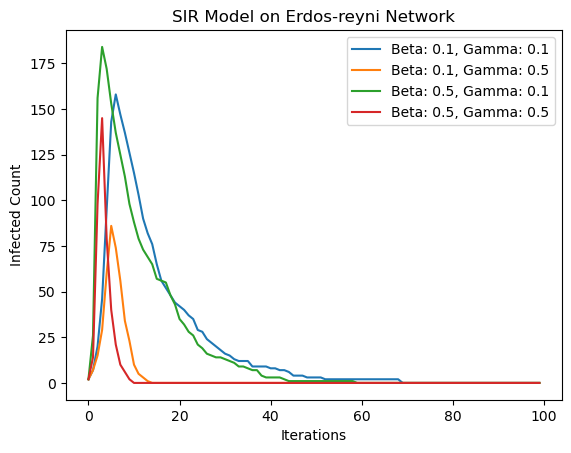

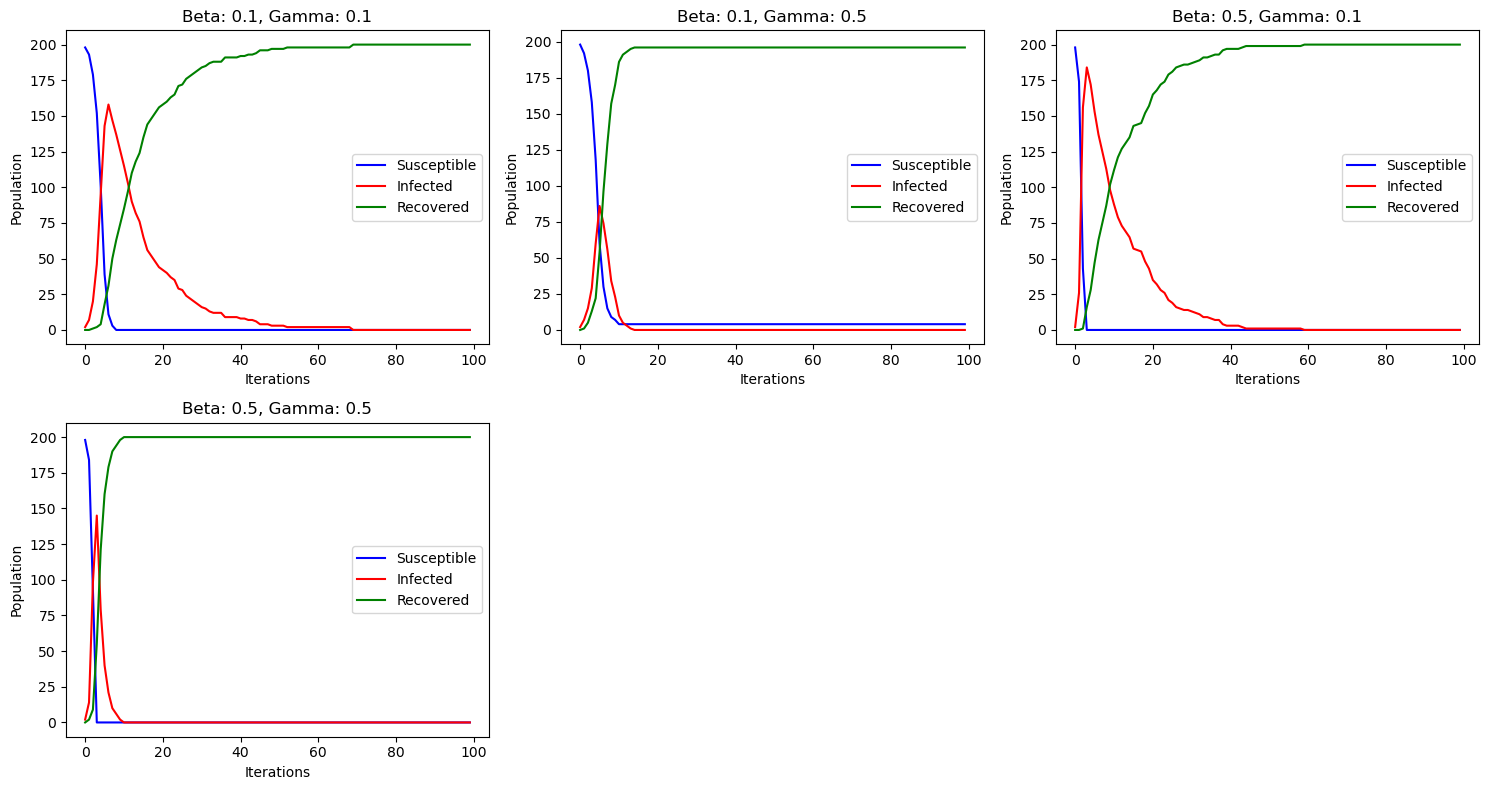

In [64]:
beta_values = np.linspace(0.1, 0.5, 2)  
gamma_values = np.linspace(0.1, 0.5, 2)  


results = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', num_nodes=200, iterations=100)
plot_sir_results(results)

## 2.2 Generate Networks of equivalent form

Using NetworkX generate multiple model networks with similar characteristics, again
think about the parameters associated with each network generator (e.g., Number of
nodes, connection probability,etc). Pick some network statistics (e.g., centrality measures,
degree distributions, etc.) that are interesting to measure in terms of spreading on the
network. You should generate multiple instances of each network type and then plot the
network statistics (you chose) and discuss how these statistic differ between network types
and for different parameter settings. You will use these generated networks in your SIR
experiments in the next part.

In [65]:
def get_diameter(network):
    return nx.diameter(network)

In [66]:
def get_average_path_length(network):
    return nx.average_shortest_path_length(network)

In [67]:
def get_average_degree(network):
    return 2 * network.number_of_edges() / network.number_of_nodes()

In [68]:
# Get degree historgram and display it
def show_degree_histogram(network):
    degree_histogram = nx.degree_histogram(network)

    # Histogram of the degrees
    degrees = range(len(degree_histogram))
    
    plt.bar(degrees, degree_histogram, color='lightgreen', edgecolor='black')
    
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.title('Degree Histogram')
    
    plt.show()

In [69]:
def show_degree_probability(network):
    degree_histogram = nx.degree_histogram(network)

    num_nodes = network.number_of_nodes()

    degree_probability = [frequency / num_nodes for frequency in degree_histogram]

    # Scatter plot of the probability
    plt.scatter(range(1, len(degree_histogram) + 1), degree_probability)

    plt.xlabel('Degree k')
    plt.ylabel('Probability p(k)')
    plt.title('Degree distributions')

    plt.show()

In [70]:
# Clustering Coefficient
# TODO

### Centrality measures

In [71]:
def get_average_degree_normalised(network):
    degree_centrality = nx.degree_centrality(network)
    
    return sum(c_d / num_nodes for c_d in degree_centrality.values())

In [72]:
def show_degree_centrality(network):
    degree_centrality = nx.degree_centrality(network)
    
    # Plot a histogram of degree centrality values
    plt.hist(list(degree_centrality.values()), bins=10, color='lightgreen', edgecolor='black')
    plt.title('Degree Centrality Distribution')
    plt.xlabel('Degree Centrality (normalised)')
    plt.ylabel('Frequency')
    plt.show()

In [73]:
def show_betweenness_centrality(network):
    betweenness_centrality = nx.betweenness_centrality(network)
    
    # Plot a histogram of betweenness centrality values
    plt.hist(list(betweenness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Betweenness Centrality Distribution')
    plt.xlabel('Betweenness Centrality')
    plt.ylabel('Frequency')
    plt.show()

In [74]:
def show_closeness_centrality(network):
    closeness_centrality = nx.closeness_centrality(network)
    
    # Plot a histogram of closeness centrality values
    plt.hist(list(closeness_centrality.values()), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Closeness Centrality Distribution')
    plt.xlabel('Closeness Centrality')
    plt.ylabel('Frequency')
    plt.show()

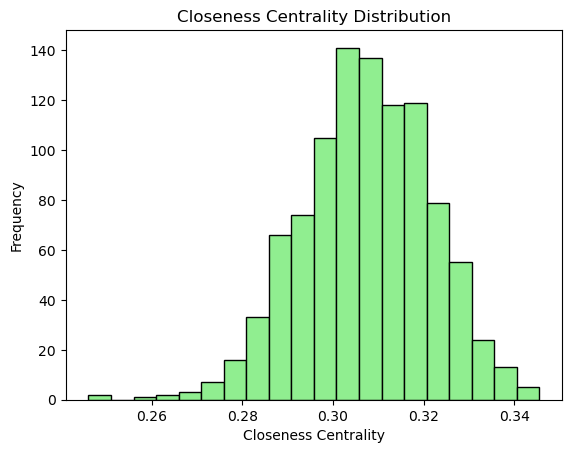

In [75]:
# Testing closeness centrality
num_nodes = 1000
p = 0.01
seed = 10
 
network = create_network('Erdos-Reyni', num_nodes, seed = seed, p = p)
show_closeness_centrality(network)

### Generate multiple networks and show statistics

In [76]:
def print_basic_network_statistics(network):
    print('Diameter =', get_diameter(network))
    print('Average path length =', get_average_path_length(network))
    print('Average degree =', get_average_degree(network))
    print('------------------------------------')

In [77]:
def generate_multiple_networks(num_networks, network_type, num_nodes, seed, p = None, m = None, k = None):
    networks = []
    
    for n in range(num_networks):
        # Generate network
        network = create_network(network_type, num_nodes, seed = seed, p = p, k = k, m = m)
        networks.append(network)

        # Update seed
        seed += 1

    return networks

In [78]:
# Generate Erdos-Reyni networks
num_networks = 5
seed = 10
num_nodes = 1000
p = 0.01
network_type = 'Erdos-Reyni'

networks = generate_multiple_networks(num_networks, network_type, num_nodes, seed, p = p)

In [79]:
# for n, network in enumerate(networks):
#     print('Statistics for network number', n + 1)
#     print_basic_network_statistics(network)

In [80]:
# Generate Barabasi-Albert networks
num_networks = 5
seed = 10
num_nodes = 1000
m = 5
network_type = 'Barabasi-Albert'

networks = generate_multiple_networks(num_networks, network_type, num_nodes, seed, m = m)

In [81]:
# for n, network in enumerate(networks):
#     print('Statistics for network number', n + 1)
#     print_basic_network_statistics(network)

In [82]:
# Generate Watts-Strogatz networks
num_networks = 5
seed = 10
num_nodes = 1000
p = 0.1
k = 10 # TODO: play with the parameters to get similar network
network_type = 'Watts-Strogatz'

networks = generate_multiple_networks(num_networks, network_type, num_nodes, seed, k = k, p = p)

In [83]:
# for n, network in enumerate(networks):
#     print('Statistics for network number', n + 1)
#     print_basic_network_statistics(network)

## 2.3 Simulate SIR spread on the network

Simulate epidemic spreading on the networks you generated in the previous section
(NOTE: the simulations will be stochastic so think about random seeds and repitions).
You can vary the fraction of initial infected, which nodes are initially infected and other
disease parameters. Compare and discuss how the disease spreads in the different networks
under different conditions.

Running simulations on Erdos-Reyni network...


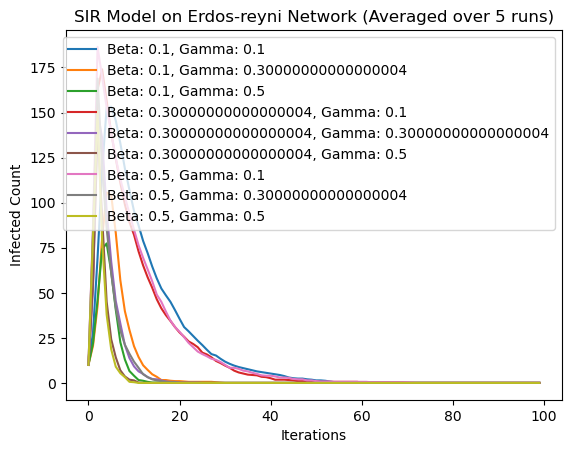

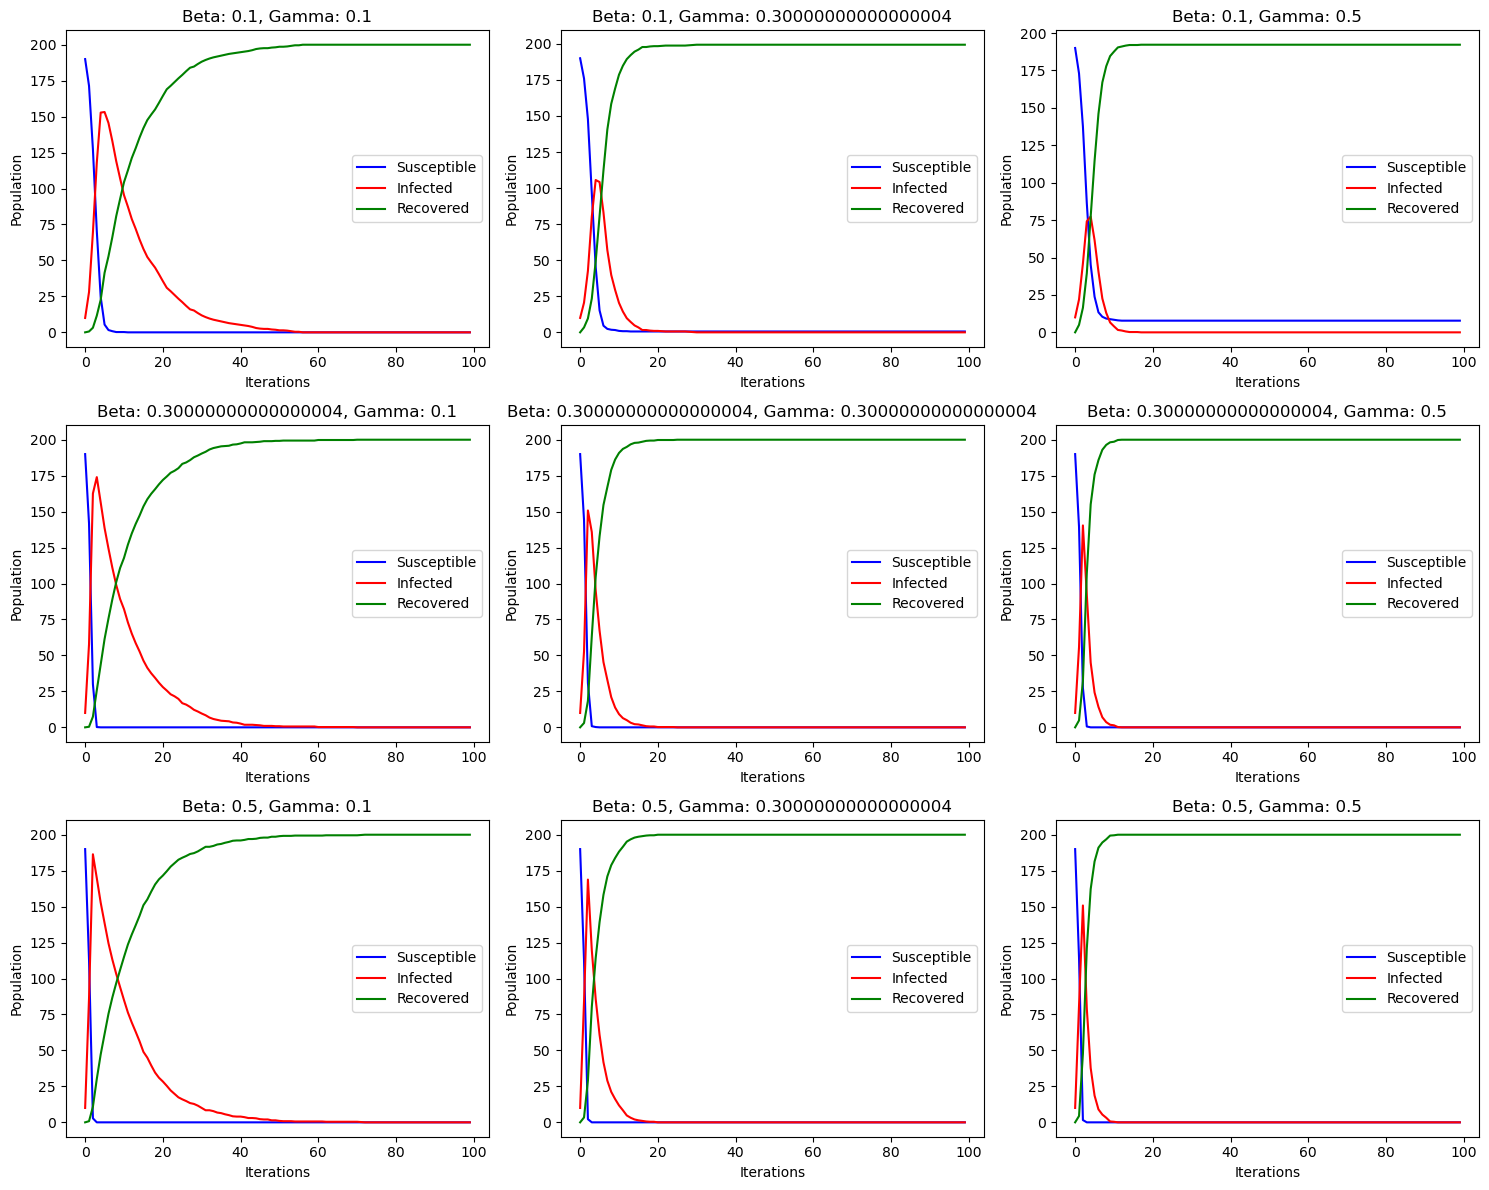

Running simulations on Barabasi-Albert network...


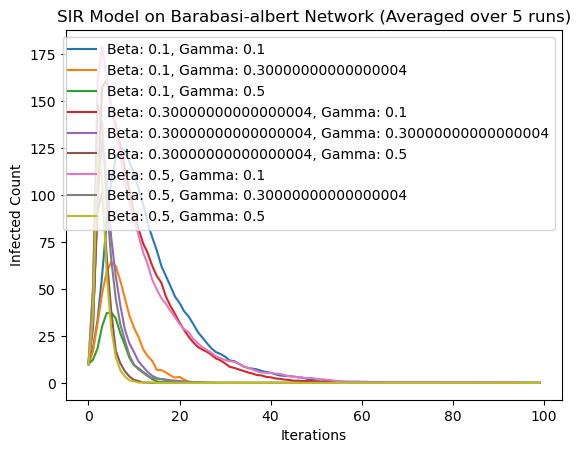

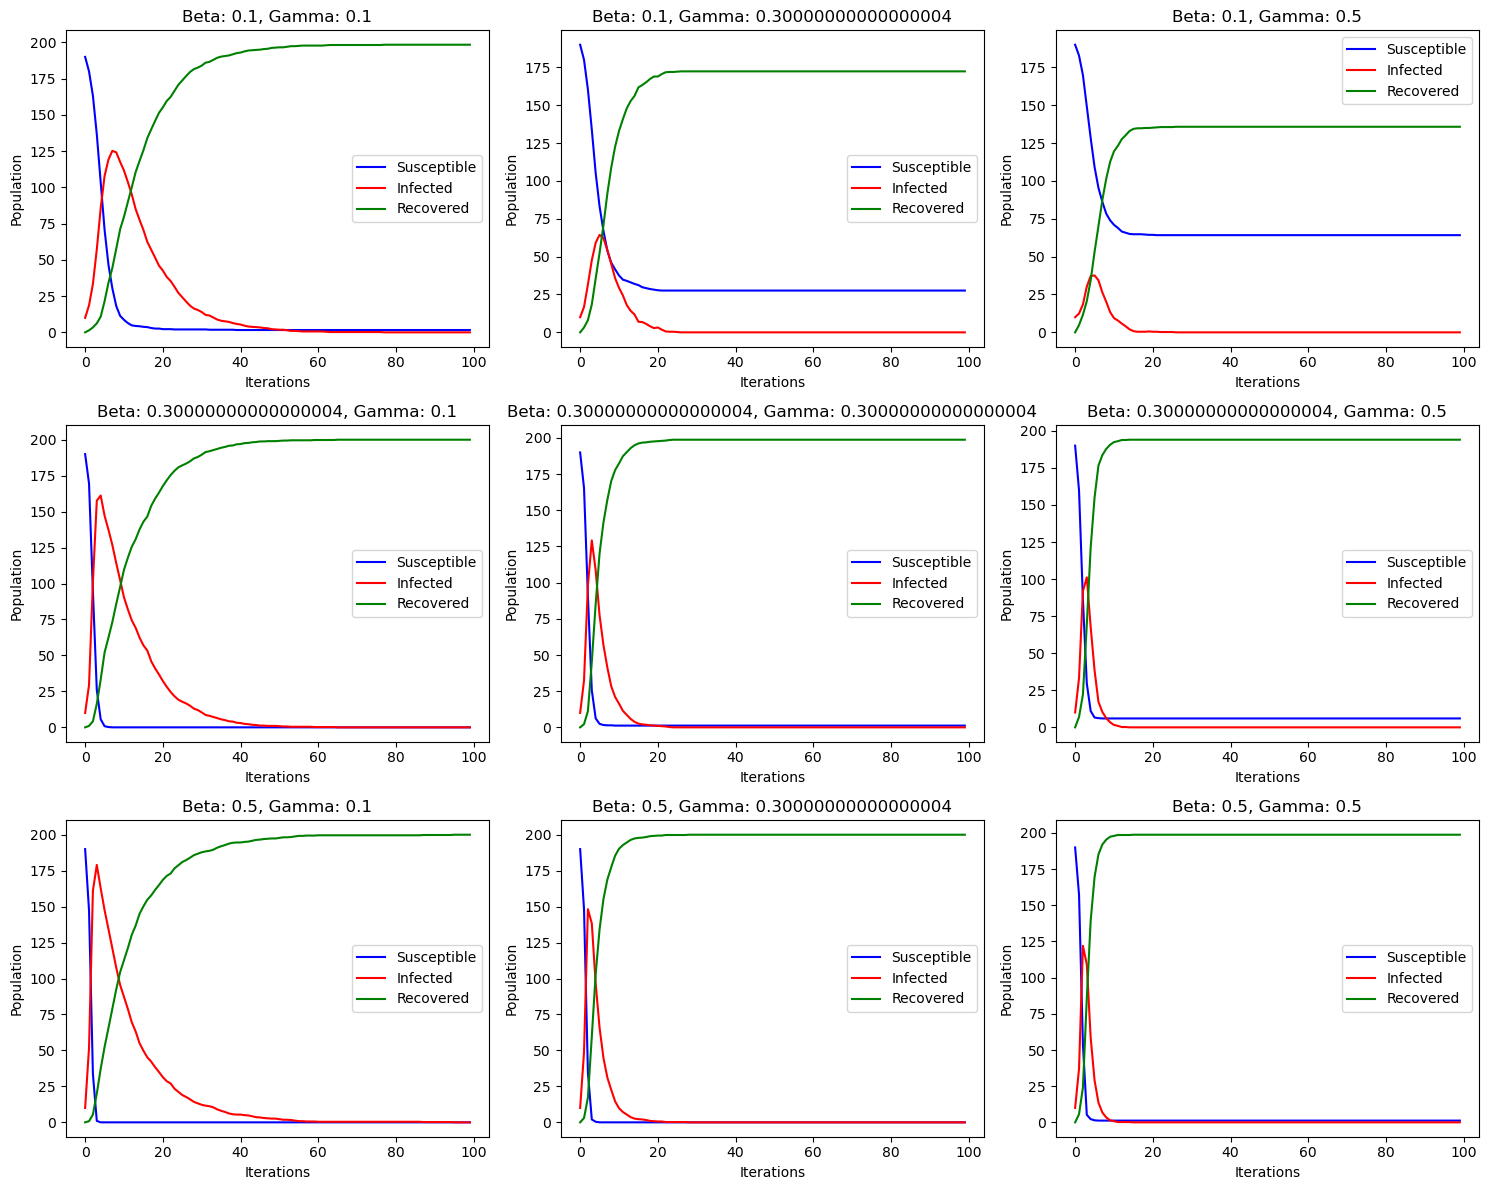

Running simulations on Watts-Strogatz network...


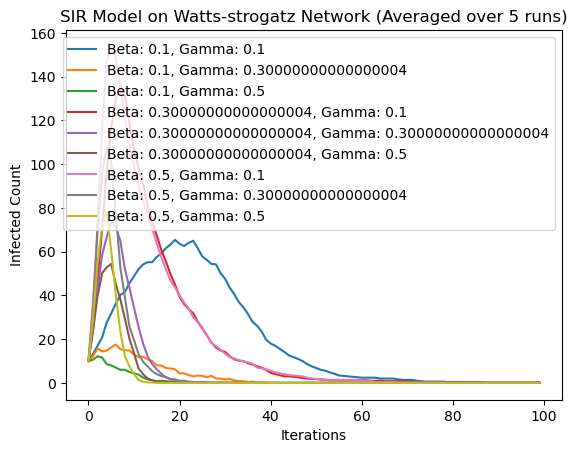

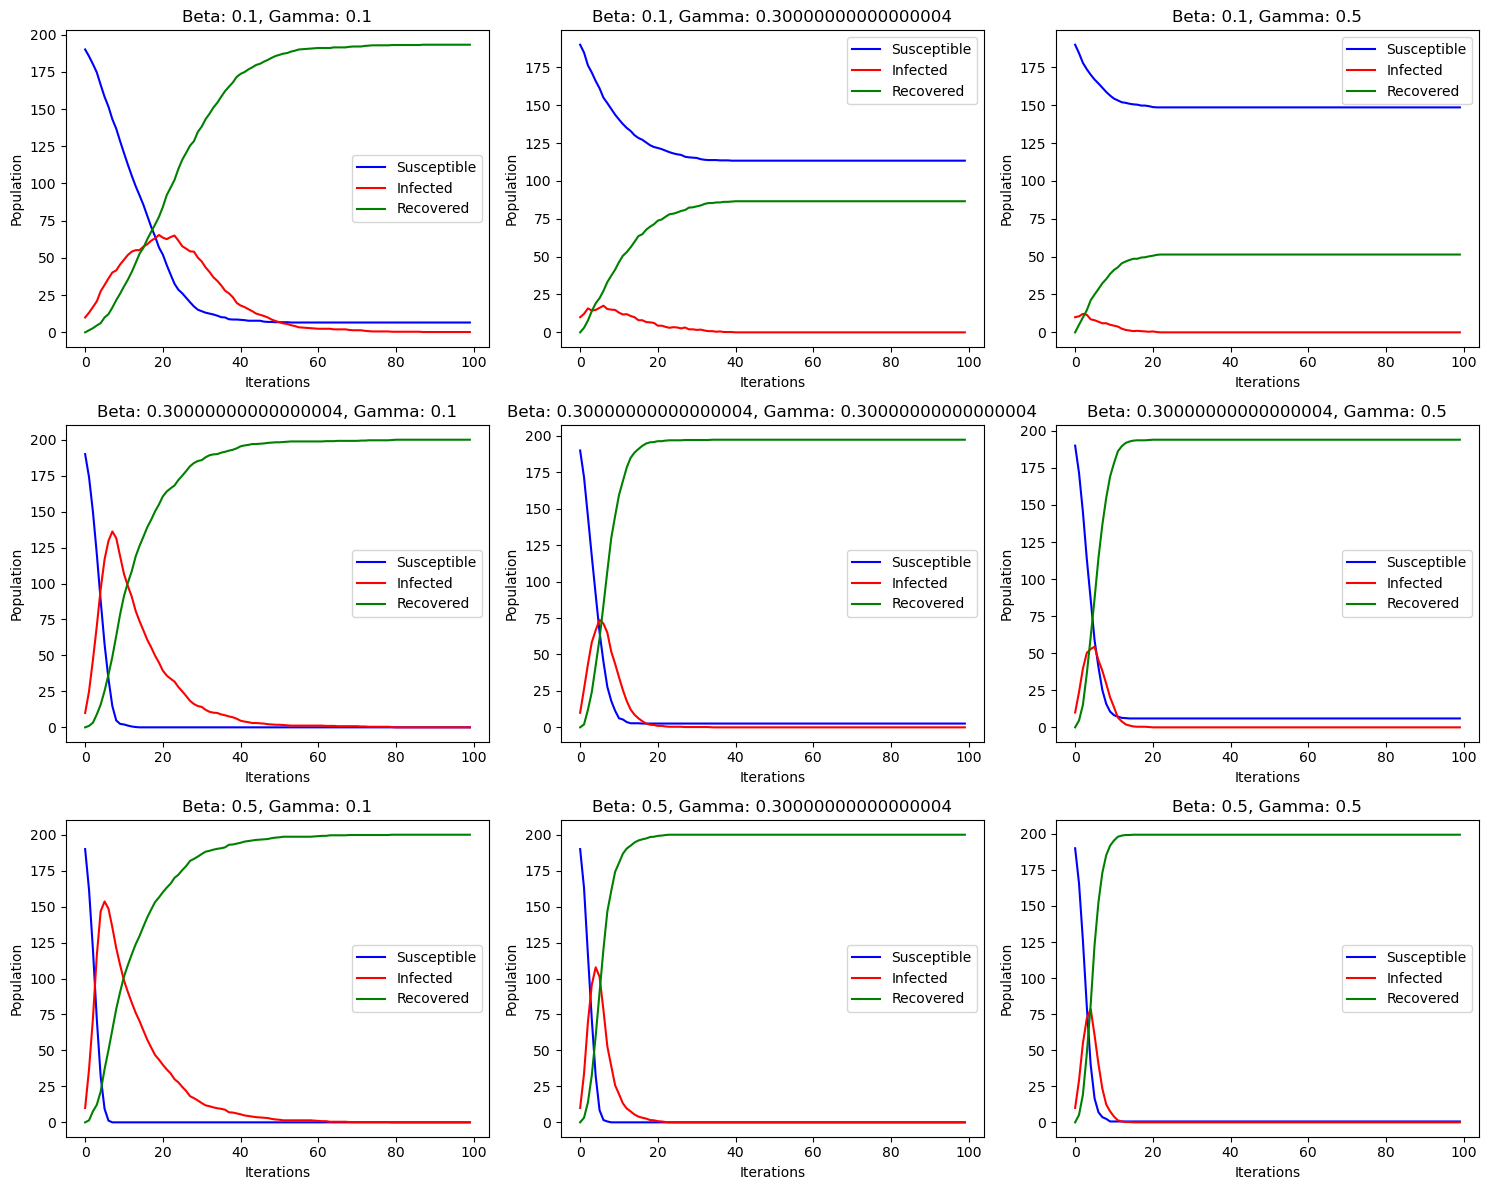

In [84]:
def experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', num_nodes=100, 
                                       initial_infected_fraction=0.01, iterations=100, repetitions=5, seed=None):
    results = {}

    # Create the network with a fixed seed for consistency
    network = create_network(network_type, num_nodes, p=0.1, seed=seed)

    # Run SIR simulations for all combinations of beta and gamma
    for beta in beta_values:
        for gamma in gamma_values:
            # Initialize accumulators for averaging across repetitions
            avg_susceptible, avg_infected, avg_recovered = None, None, None

            for rep in range(repetitions):
                susceptible, infected, recovered = run_sir_simulation(network, beta, gamma, initial_infected_fraction, iterations, seed=seed+rep)
                
                if avg_susceptible is None:
                    avg_susceptible = np.array(susceptible, dtype=float)
                    avg_infected = np.array(infected, dtype=float)
                    avg_recovered = np.array(recovered, dtype=float)
    

                else:
                    avg_susceptible += np.array(susceptible)
                    avg_infected += np.array(infected)
                    avg_recovered += np.array(recovered)

            # Average the results over repetitions
            avg_susceptible /= repetitions
            avg_infected /= repetitions
            avg_recovered /= repetitions

            # Store results
            results[(beta, gamma)] = (avg_susceptible, avg_infected, avg_recovered)

            # Plot the infected curve for each beta, gamma pair
            plt.plot(avg_infected, label=f'Beta: {beta}, Gamma: {gamma}')
    
    plt.title(f'SIR Model on {network_type.capitalize()} Network (Averaged over {repetitions} runs)')
    plt.xlabel('Iterations')
    plt.ylabel('Infected Count')
    plt.legend()
    plt.show()

    return results

# Define parameters for the experiment
beta_values = np.linspace(0.1, 0.5, 3)  # Infection probabilities to explore
gamma_values = np.linspace(0.1, 0.5, 3)  # Recovery probabilities to explore
network_types = ['Erdos-Reyni', 'Barabasi-Albert', 'Watts-Strogatz']  # Different network types
num_nodes = 200  # Number of nodes in the network
initial_infected_fraction = 0.05  # Fraction of initial infected population
iterations = 100  # Number of iterations for the SIR model
repetitions = 5  # Number of repetitions to smooth out randomness
seed = 42  # Base seed for stochasticity control

# Run experiments on each network type and plot the results
for network_type in network_types:
    print(f"Running simulations on {network_type} network...")
    results = experiment_with_varying_parameters(beta_values, gamma_values, network_type=network_type, 
                                                 num_nodes=num_nodes, initial_infected_fraction=initial_infected_fraction, 
                                                 iterations=iterations, repetitions=repetitions, seed=seed)
    plot_sir_results(results)

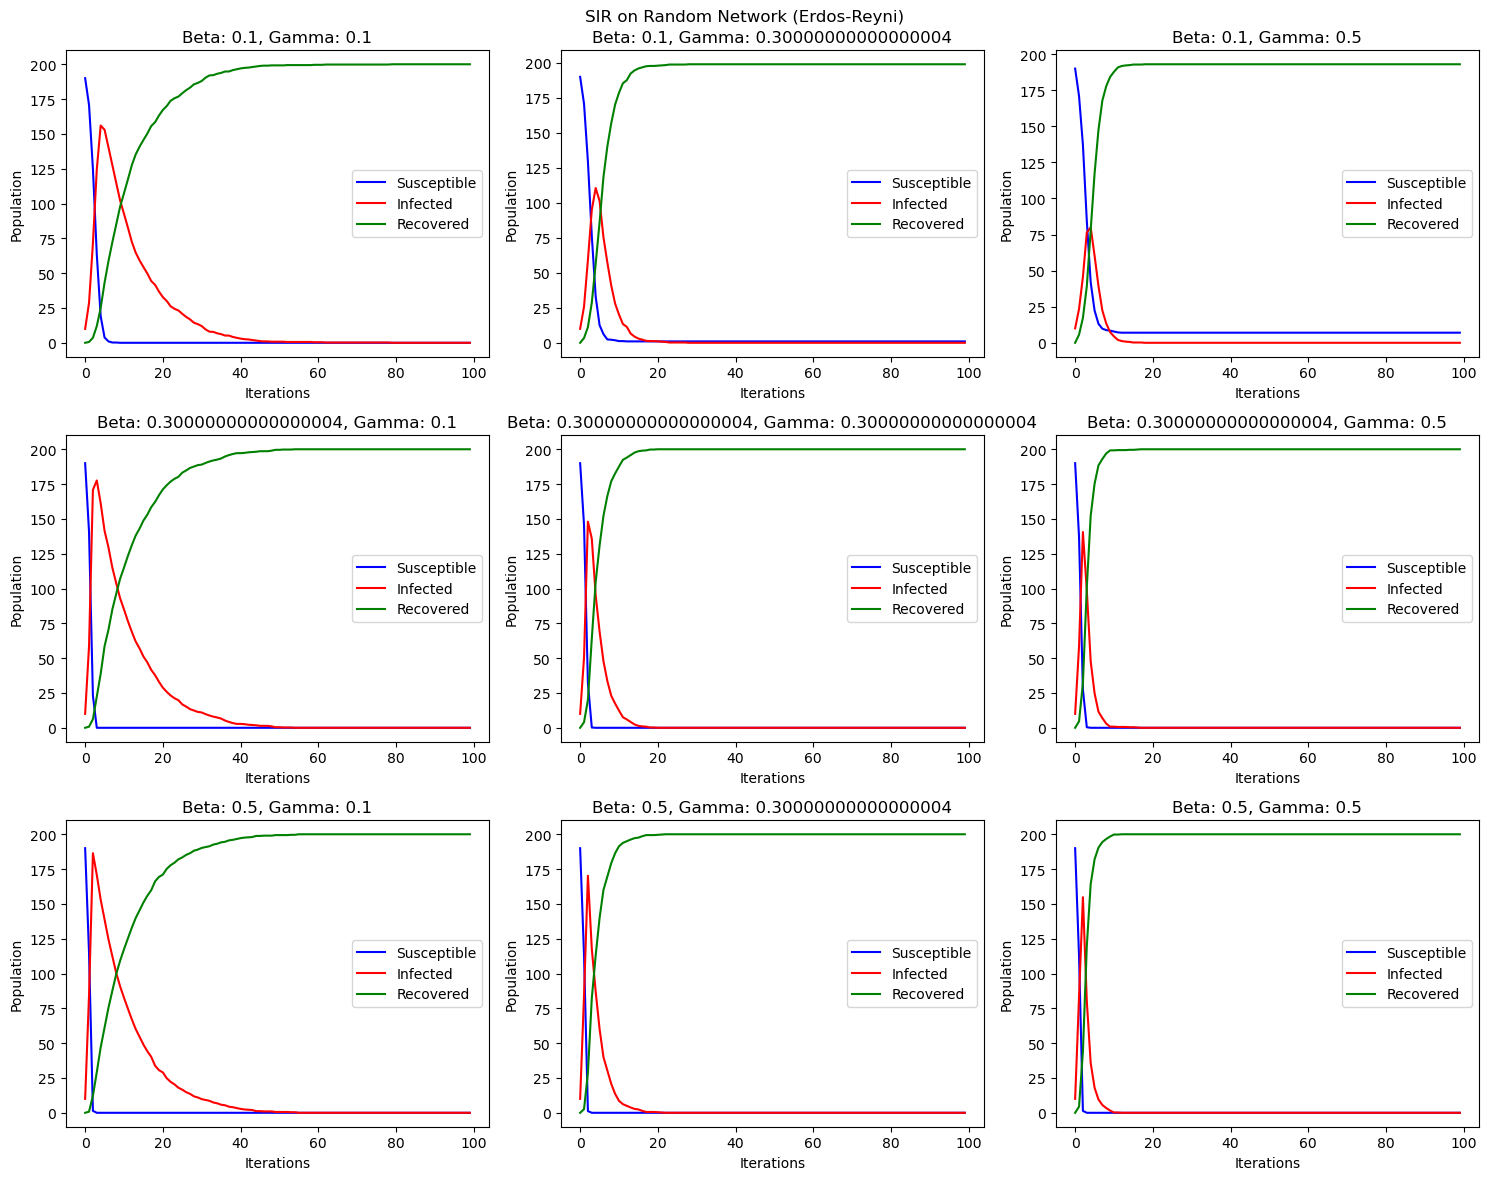

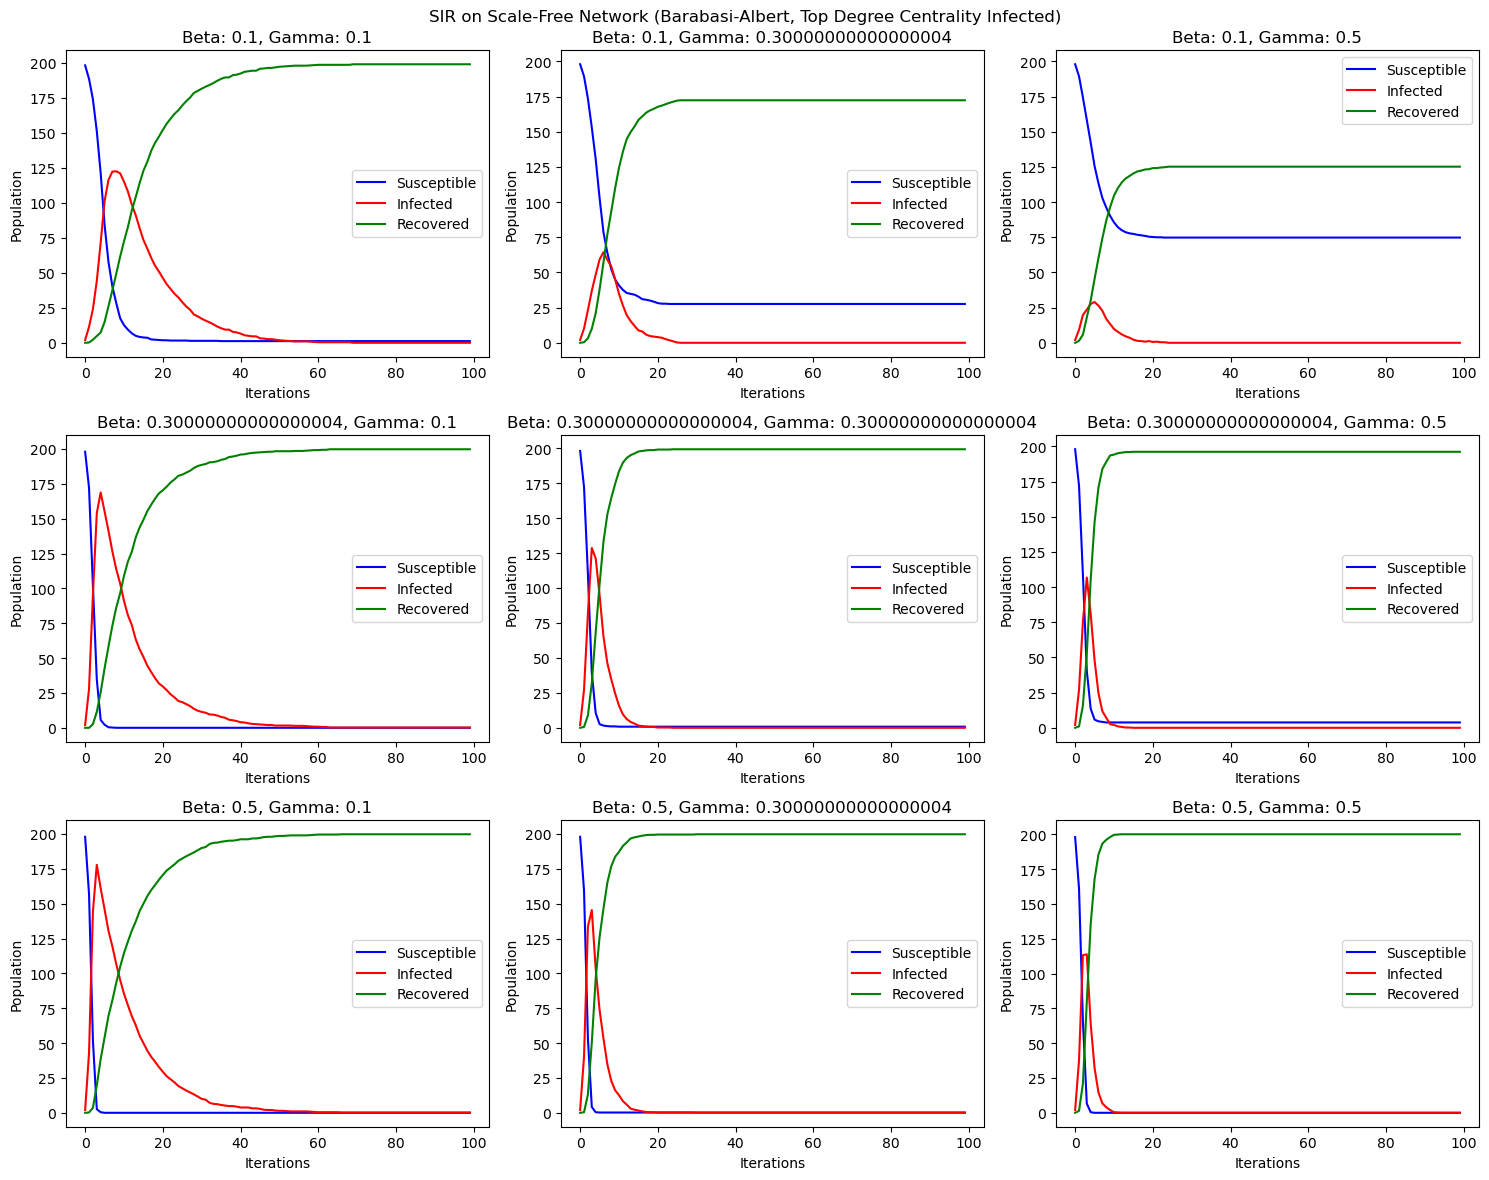

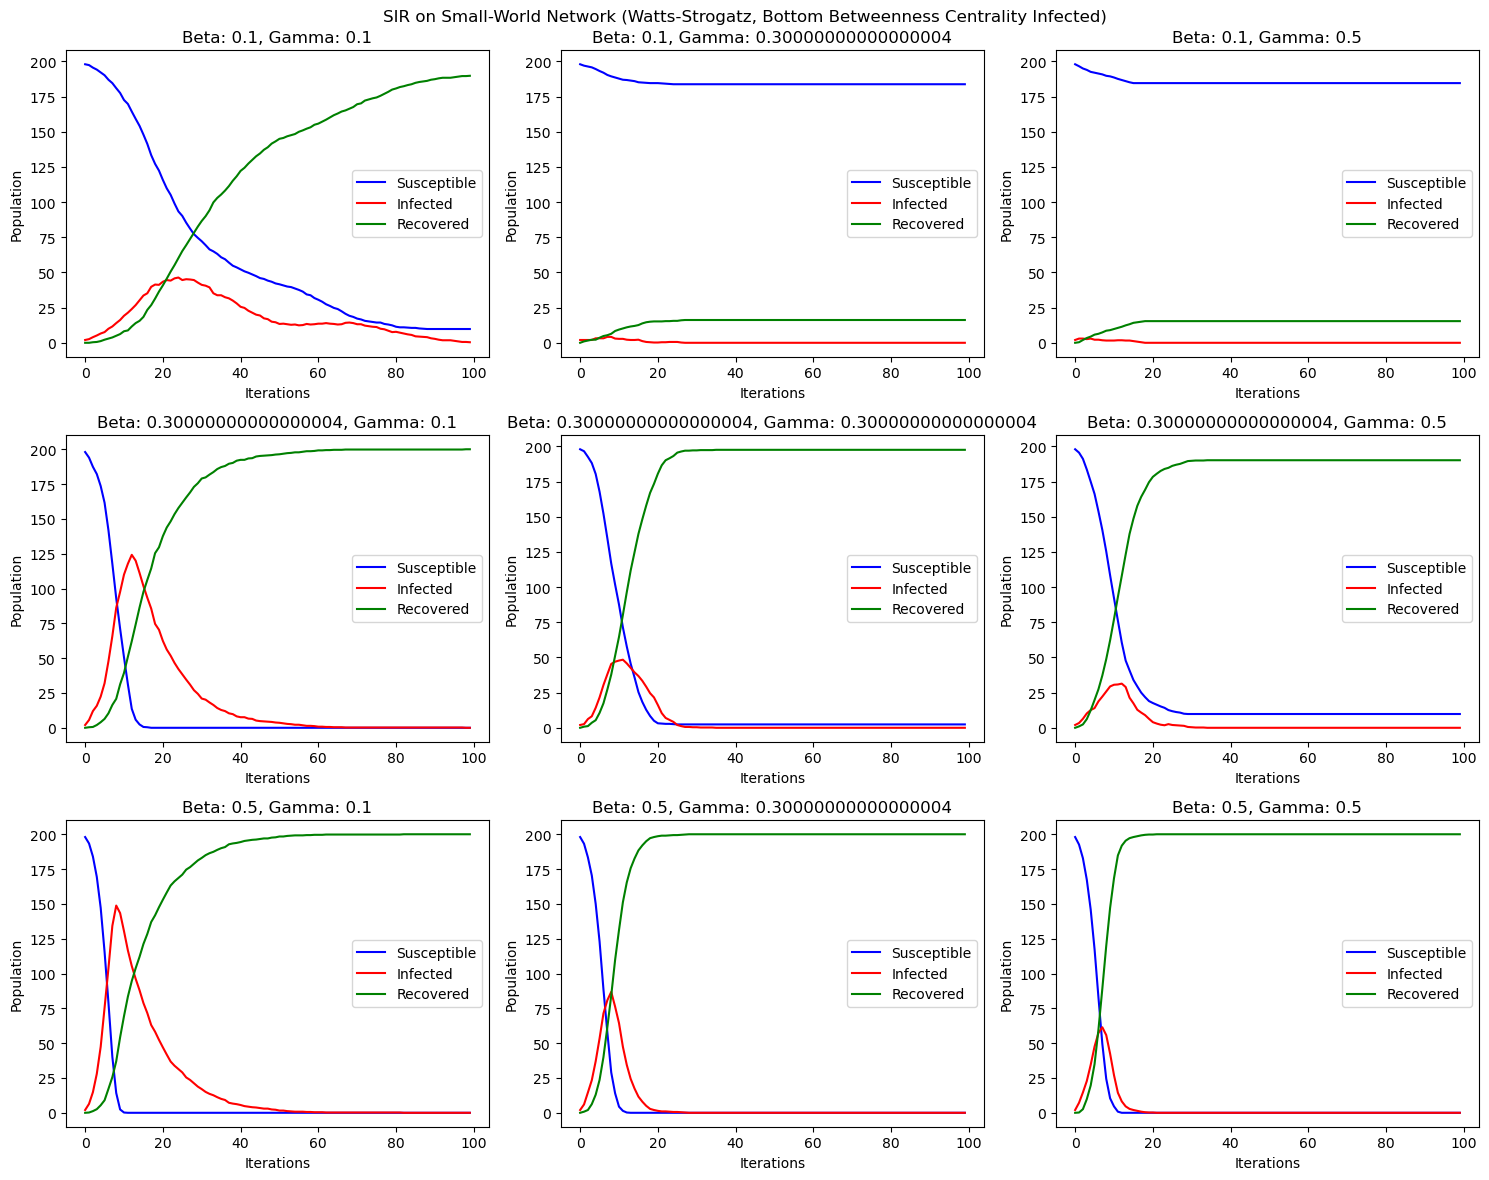

In [85]:
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Function to create networks based on the type
def create_network(network_type, num_nodes, seed=None, p=0.01, m=5, k=6):
    if network_type == 'Erdos-Reyni':
        return nx.erdos_renyi_graph(num_nodes, p, seed)
    elif network_type == 'Barabasi-Albert':
        return nx.barabasi_albert_graph(num_nodes, m, seed)
    elif network_type == 'Watts-Strogatz':
        return nx.watts_strogatz_graph(num_nodes, k, p, seed)
    else:
        raise ValueError("Invalid network type. Choose from 'Erdos-Reyni', 'Barabasi-Albert', or 'Watts-Strogatz'.")

# Function to run SIR simulation
def run_sir_simulation(network, beta, gamma, initial_infected_fraction=None, initial_infected_nodes=None, iterations=100):
    # Configuring the model
    model = ep.SIRModel(network)
    config = mc.Configuration()
    config.add_model_parameter('beta', beta)
    config.add_model_parameter('gamma', gamma)

    # Set initial infected population (either by fraction or specific nodes)
    if initial_infected_fraction is not None:
        config.add_model_parameter("percentage_infected", initial_infected_fraction)
    elif initial_infected_nodes is not None:
        config.add_model_initial_configuration("Infected", initial_infected_nodes)

    model.set_initial_status(config)

    # Simulate the model
    trends = model.iteration_bunch(iterations)

    susceptible = [trend['node_count'][0] for trend in trends]
    infected = [trend['node_count'][1] for trend in trends]
    recovered = [trend['node_count'][2] for trend in trends]

    return susceptible, infected, recovered

# Function to plot SIR results
def plot_sir_results(results, title):
    """
    Function to plot SIR curves for all combinations of beta and gamma.
    """
    num_plots = len(results)
    cols = 3  # Number of columns in the plot grid
    rows = (num_plots // cols) + (num_plots % cols > 0)

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()

    for idx, ((beta, gamma), (susceptible, infected, recovered)) in enumerate(results.items()):
        ax = axes[idx]
        ax.plot(susceptible, label='Susceptible', color='blue')
        ax.plot(infected, label='Infected', color='red')
        ax.plot(recovered, label='Recovered', color='green')

        ax.set_title(f"Beta: {beta}, Gamma: {gamma}")
        ax.set_xlabel('Iterations')
        ax.set_ylabel('Population')
        ax.legend()

    # Hide any unused subplots
    for idx in range(len(results), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Function to calculate centralities and select top/bottom nodes
def get_centrality_nodes(network, centrality_type, fraction=0.01, top=True):
    centrality = None
    if centrality_type == "degree":
        centrality = nx.degree_centrality(network)
    elif centrality_type == "betweenness":
        centrality = nx.betweenness_centrality(network)
    elif centrality_type == "closeness":
        centrality = nx.closeness_centrality(network)
    else:
        raise ValueError("Invalid centrality type. Choose from 'degree', 'betweenness', or 'closeness'.")

    sorted_nodes = sorted(centrality.items(), key=lambda item: item[1], reverse=top)
    num_infected = int(fraction * len(network.nodes))
    return [node for node, _ in sorted_nodes[:num_infected]]

# Function to run experiments with varying parameters and centrality-based infections
def experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', num_nodes=100, 
                                       initial_infected_fraction=None, initial_infected_nodes=None, 
                                       centrality_type=None, iterations=100, repetitions=5, seed=10, top=True):
    results = {}

    # Create the network
    network = create_network(network_type, num_nodes, p=0.1, seed=seed)

    # Set up initial infected nodes based on centrality if required
    if centrality_type is not None:
        initial_infected_nodes = get_centrality_nodes(network, centrality_type, fraction=initial_infected_fraction, top=top)

    # Run SIR simulations for all combinations of beta and gamma
    for beta in beta_values:
        for gamma in gamma_values:
            # Initialize accumulators for averaging across repetitions
            avg_susceptible, avg_infected, avg_recovered = None, None, None

            for rep in range(repetitions):
                susceptible, infected, recovered = run_sir_simulation(
                    network, beta, gamma, initial_infected_fraction=initial_infected_fraction if initial_infected_nodes is None else None,
                    initial_infected_nodes=initial_infected_nodes if initial_infected_nodes is not None else None, 
                    iterations=iterations
                )

                # Accumulate results
                if avg_susceptible is None:
                    avg_susceptible = np.array(susceptible, dtype=float)
                    avg_infected = np.array(infected, dtype=float)
                    avg_recovered = np.array(recovered, dtype=float)
                else:
                    avg_susceptible += np.array(susceptible)
                    avg_infected += np.array(infected)
                    avg_recovered += np.array(recovered)

            # Average the results over repetitions
            avg_susceptible /= repetitions
            avg_infected /= repetitions
            avg_recovered /= repetitions

            # Store the results
            results[(beta, gamma)] = (avg_susceptible, avg_infected, avg_recovered)

    return results

# Test and compare different network types with various infection conditions
beta_values = np.linspace(0.1, 0.5, 3)
gamma_values = np.linspace(0.1, 0.5, 3)

# 1. Vary percentage_infected
results_random = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', 
                                                    num_nodes=200, initial_infected_fraction=0.05, iterations=100)
plot_sir_results(results_random, "SIR on Random Network (Erdos-Reyni)")

# 2. Infect nodes based on degree centrality (top 1%)
results_degree = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', 
                                                    num_nodes=200, centrality_type='degree', initial_infected_fraction=0.01, iterations=100, top=True)
plot_sir_results(results_degree, "SIR on Scale-Free Network (Barabasi-Albert, Top Degree Centrality Infected)")

# 3. Infect nodes with least betweenness centrality (bottom 1%)
results_low_betweenness = experiment_with_varying_parameters(beta_values, gamma_values, network_type='Erdos-Reyni', 
                                                             num_nodes=200, centrality_type='betweenness', initial_infected_fraction=0.01, iterations=100, top=False)
plot_sir_results(results_low_betweenness, "SIR on Small-World Network (Watts-Strogatz, Bottom Betweenness Centrality Infected)")


## 2.4 Dynamic Vaccination Campaign

Finally, we will conduct vaccination experiments using the sociopatterns dataset, see
Figure 1. You should design some code to load in the sociopatterns dataset (this file on
canvas includes a simple edgelist and NDLib and NetworkX provide ways to import this).

Now consider a scenario in which a disease is spreading on this network. You should run
multiple experiments, but assume that the disease always starts with a random selection
of 5 nodes infected.

You are to design a dynamic vaccination strategy in which you have a testing budget and
a limited number of vaccinations available per iteration of the model. Assume that you
have 200 tests in total, you can use a maximum number of tests per iteration (this will
vary per experiment see below), you can of course use less. You can use the tests at any
point during the spread and you may repeat tests on a node as often as you like. You
can assume that you know the network structure, but you can only discover the disease
status of a node after a test. Vaccinations can only be applied to susceptible people and
that they immediately move people to the removed state. Finally, you might consider
situations where the tests are not always accurate, but instead have some probability
(which you can vary) of being accurate. You can also assume that people remain removed
until the end of the simulation (no waning immunity).
You should compare your strategy against a simple null strategy which randomly assigns
vaccinations, you should design a strategy that at least out performs the null strategy.
Compare the strategies with different vaccination budgets of [1, 3, 5 and 10] per timestep
and compare with different testing accuracy [0.5, 0.75, 1.0] . Finally, keep in mind that
the purpose of the assignment is not to design the best strategy, but to evaluate you
strategy in a systematic and scientific manner.